In [7]:
import numpy as np
import matplotlib.pyplot as plt

from pimcs import jspin, destroy, Dicke, rotated_qubits, mcsolve

# setup system in exactly same way as with qutip.piqs
N = 50
OmegaC = 0
OmegaA = 0.1/2
Coupling = 0.1 / np.sqrt(N)

a = destroy(4) # increase cavity truncation if needed (varies depending on problem)
               # if unsure, set higher at small N, then keep decreasing if results do not change,
               # then keep it at this value for large N - should not need to grow with N.

Jz = jspin(N, 'z')
Jp = jspin(N, '+')
Jm = jspin(N, '-')

H = OmegaC * a.dag()*a + OmegaA * 2*Jz + Coupling * (Jp * a + Jm * a.dag())
system = Dicke(N, H, cavity_loss = 0.01, dephasing = 0.01)

psi0 = rotated_qubits(N, 0.1 * np.pi)
times = np.linspace(0, 128, 300)

data = mcsolve(
    system,
    psi0,               # initial state of simulations
    times,              # times to output expecation values (must be linearly spaced for now)
    [a.dag()*a, Jz],    # operators of expectation values to output
    ntraj = 400,        # number of Monte Carlo simulations to run 
    ncpu = 8,           # number of simulations to run in parallel (ideally = number of CPU cores)
    jtol = 0.05,        # parameter to tune integration step size (lower is more accurate but slower)
)

data2 = mcsolve(
    system,
    psi0,
    times,
    [a.dag()*a, Jz],
    ntraj = 400,
    ncpu = 8,
    jtol = 0.05,
    disable_displ = True, # do not use transform for second run
)

Building optimized executable...
Running trajectories...


Running backend with UseDisplacement = Yes
Trajectory [400/400] completed, average time: 0.012 seconds.


Building optimized executable...
Running trajectories...


Running backend with UseDisplacement = No
Trajectory [400/400] completed, average time: 0.005 seconds.


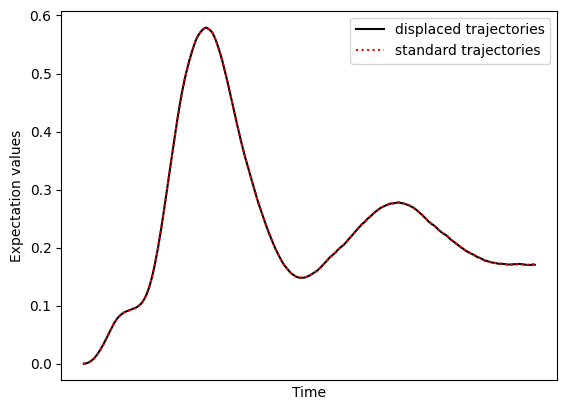

In [8]:
# obtain expectation values the same way as from qutip
# these are all complex for now: smarter Hermitian detection will come later

photon = data.expect[0].real
# spin = data.expect[1].real

photon2 = data2.expect[0].real
# spin2 = data2.expect[1].real

plt.plot(times, photon / N, c = 'k', label = "displaced trajectories")
# plt.plot(times, spin / N, label = "z-spin")

plt.plot(times, photon / N, c = 'r', ls = ":", label = "standard trajectories")
# plt.plot(times, spin / N, ls = "--")

plt.xticks([])
plt.xlabel("Time")
plt.ylabel("Expectation values")
plt.legend(loc = "upper right")